# HD 104438

We observed this target with SHARK-VIS ~1 year ago. The results are published here:

https://ui.adsabs.harvard.edu/abs/2025ApJ...981...94R/abstract

The companion we detected to HD 104438 is actually a distant third body (see Figure 5a). We recently reobserved this system with SHARK-VIS and now see all three stars.

With this new observation and the archival RVs, we (i.e. you) will be able to place constraints on the masses and orbital inclination, as we did for HD 176695 (see Figure 10c). The SHARK-VIS team will supply the measured angular separation. It is probably ~70 or 80mas if you want a number to test your code. The file "HD10443_RVs.csv" gives the radial velocities, and there some additional measurements I added in manually below. 

The RVs are also available online here:

https://sb9.astro.ulb.ac.be//ProcessMainform.cgi?Catalog=HD&Id=104438&Coord=&Epoch=2000&radius=10&unit=arc+min

This link also includes an archival fit to the orbit, which you may find useful. 

You'll notice that there are multiple instruments used to measure the RV. There are typically RV offsets between different instruments that reflect wavelenght calibration. The way around this is to just fit for a constant RV offset parameter for each instrument in your model. You could just use the RV offsets I fit in Table 3 of the paper as a starting point. 


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def plotparams(ax, labelsize=15):
    '''
    Basic plot params

    :param ax: axes to modify

    :type ax: matplotlib axes object

    :returns: modified matplotlib axes object
    '''
    ax.minorticks_on()
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(direction='in', which='both', labelsize=labelsize)
    ax.tick_params('both', length=8, width=1.8, which='major')
    ax.tick_params('both', length=4, width=1, which='minor')
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.5)
    return ax

In [4]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('HD104438_RVs.csv')

# Check the first few rows to understand the structure of the data
print(df.iloc[:,0:2])


             JD      RV
0   2421768.160  33.300
1   2421941.550  32.800
2   2421972.520  29.600
3   2423120.310  29.400
4   2423128.380  29.800
..          ...     ...
70  2453888.970  25.100
71  2454078.300  25.000
72  2454249.970  24.800
73  2454471.250  24.600
74  2456337.762  21.105

[75 rows x 2 columns]


Text(0, 0.5, 'Radial Velocity [km/s]')

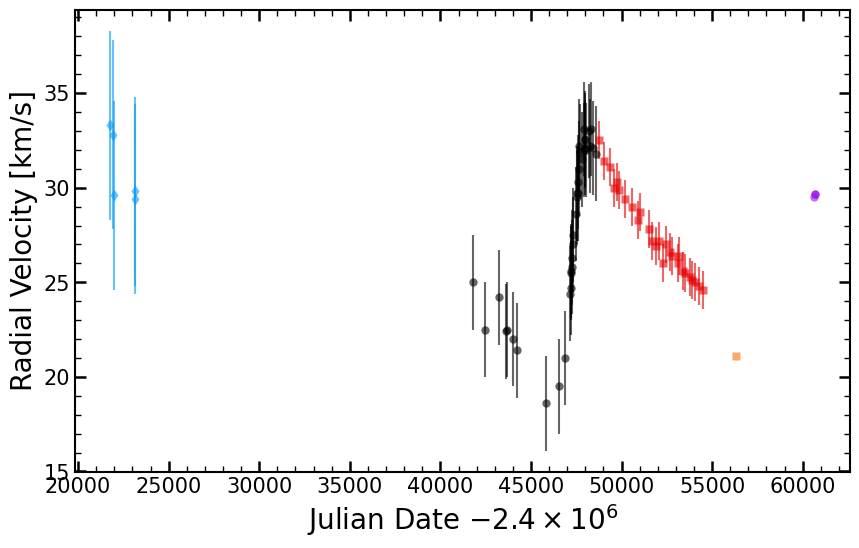

In [5]:
df = pd.read_csv('HD104438_RVs.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax = plotparams(ax)

instrument_weights = {
    1.0: 'CORAVEL',
    0.25: 'Cambridge Spectrometer',
    0.025: 'Mount Wilson 60inch'
}

rv_err_weights = {
    1.0: 1,
    0.25: 2.5,
    0.025: 5.0
}

df['Instrument'] = df.Weight.map(instrument_weights)
df['RV_err'] = df.Weight.map(rv_err_weights)

df_apogee = pd.DataFrame({'JD':[2456337.762], 'RV': [21.105],
                          'RV_err':[0.02474], 'Instrument':['APOGEE'], 'Weight':[1.0]})

df_apf = pd.DataFrame({'JD':[2460648.893223666, 2460663.8506141417, 2460653.898714318],
                       'RV':[29.51, 29.68, 29.65]})
df_apf['Instrument'] = 'APF'
df_apf['Weight'] = 1.0

df = pd.concat([df, df_apogee, df_apf])

instrument_list = df.Instrument.value_counts().index
markers = ['o', 's', 'd', 'o', 's']
colors = ['black', 'xkcd:red', 'xkcd:azure', 'xkcd:violet', 'xkcd:orange']

for instrument, marker, color in zip(instrument_list, markers, colors):
    ax.errorbar(df[df.Instrument == instrument].JD - 2.4e6, df[df.Instrument == instrument].RV, 
                yerr=df[df.Instrument == instrument].RV_err, marker=marker, color=color, ls='',
                markeredgecolor='none', alpha=0.6)

ax.set_xlabel(r'Julian Date $ - 2.4\times10^6$', fontsize=20)
ax.set_ylabel('Radial Velocity [km/s]', fontsize=20)


I tried calculating msin(i)?

In [6]:
offsets = {
    1.0: 1.4,
    0.25: 1.1,
    0.025: 0
}

In [89]:
df['RV_err']
df[

0     5.00000
1     5.00000
2     5.00000
3     5.00000
4     5.00000
       ...   
74        NaN
0     0.02474
0         NaN
1         NaN
2         NaN
Name: RV_err, Length: 79, dtype: float64

In [7]:
import numpy as np
from astropy.constants import G, M_sun
from astropy import units as u

def compute_msin_i(P_days, K_kms, e, M1_solar):
    # Convert units
    P = (P_days * u.day)#.to(u.s)
    K = (K_kms * u.km/u.s).to(u.AU/u.day)
    M1 = M1_solar* u.M_sun
    g = G.to(u.au**3 / u.M_sun / u.day**2)

    # Compute M2 sin(i) in kg
    factor = (K * P**(1/3) * (1 - e**2)**0.5) / (2 * np.pi * g)**(1/3)
    msini = factor * M1**(2/3)

    #M2 sin(i)
   # msini = (K**3 * P / (2 * np.pi * g))**(1/3)

    return msini.value


In [8]:
msini = compute_msin_i(13000, 6.7, .58, 0.22)
print(msini,'Msun')

0.21966707949549916 Msun


In [9]:
from astropy.constants import G, M_sun
from astropy import units as u

def semi_major_axis(P_days, M1, M2):
    P = P_days * u.day
    Mtot = (M1 + M2) * M_sun
    a = ((G * Mtot * P**2) / (4 * np.pi**2))**(1/3)
    return a.to(u.au)


In [10]:
def angular_separation(a_au, d_pc):
    theta_arcsec = (a_au / d_pc) * u.arcsec
    return theta_arcsec.to(u.mas)


In [11]:
#sep = angular_separation(, )
#print(sep)


__First, use MCMC methods to constrain the RV orbit__

"For each target, we fit the archival RVs using a Keplerian
orbit model of the form 

RV(𝑡) = 𝛾 + 𝐾 [(𝜔 + 𝑓 ) + 𝑒 cos𝜔] 

where 𝛾 is the center-of-mass velocity, 𝐾 is the radial velocity
semiamplitudes, 𝑓 is the true anomaly, and 𝜔 is the argument
of periastron. The true anomaly, 𝑓 , is defined based on the
eccentric anomaly, 𝐸, and the eccentricity, 𝑒 by

cos 𝑓 =
cos 𝐸 − 𝑒
1 − 𝑒 cos �

and the eccentric anomaly is
𝐸 − 𝑒 sin 𝐸 =
2𝜋(𝑡 − 𝑇0)
𝑃
(4)
where 𝑃 is the period and 𝑇0 is the time of periastron."

--> (https://arxiv.org/pdf/2410.19050) page 6

In [416]:
def keplerian_model(t, P, K, e, f, gamma, omega, T0, offset):
   #Is period not an input here? Or does it relate to something else?
    # compute RV using:
    RV = gamma + K *((f + omega) + e*np.cos(omega)) + offset #eqtn from paper

    return RV


In [417]:
import emcee
#help(emcee)

Use emcee to sample over all the orbital parameter inputs to my Kepler function?

In the paper they estimated f, is that what I should do?

Do I need to be concerned with the stellar jitter term?


Run MCMC chain for 50,000 iterations

Discard first 10,000 iterations

In [418]:
# what am i doing
print(df.iloc[:,2])

0     0.02500
1     0.02500
2     0.02500
3     0.02500
4     0.02500
       ...   
74    0.02474
0     1.00000
0     1.00000
1     1.00000
2     1.00000
Name: Weight, Length: 79, dtype: float64


In [430]:
# For HD104438 with RV offset #1 (coravel)

# Fixed parameters:
P = 13000
K = 6.7
t = df.iloc[:,0]


# These parameters will be getting constrained:
e = .58
f = .22
gamma = 24.2
omega = -80
T0 = 1400
offset = 1.4

#idk!:
rv_obs = df.iloc[:,1]
rv_err = df.iloc[:,2] # is this how im supposed to do it or should i use iloc; df['RV_err'] 


params = np.array([e, f, gamma, omega, T0]) #should i be concerned with factoring in the offset rn ; these parameters will vary (fix period and K)

All code from https://emcee.readthedocs.io/en/stable/user/sampler/#emcee.EnsembleSampler

In [420]:
def log_likelihood(params, t, P, K, rv_obs, rv_err, offset): #should it be *params
    model_rv = keplerian_model(t, P, K, *params, offset)
    return -0.5 * np.sum(((rv_obs - model_rv) / rv_err)**2 + np.log(2 * np.pi * rv_err**2))


In [421]:
def log_prior(params): # prior info (should this be a uniform prior)
    e, f, gamma, omega, T0 = params #should i factor in the jitter stuff here too; didnt include col w offset
    if 0 < e < 1 and f > 0:# make sure that the priors are possible values
        return 0.0  # Uniform prior
    return -np.inf  # log(0) so reject the sample bc not possible ?


In [422]:
def log_probability(params, t, P, K, rv_obs, rv_err, offset): # probability of the posterior
    lp = log_prior(params)
    if not np.isfinite(lp): #if it's not a possible value then the code won't break
        return -np.inf
    return lp + log_likelihood(params, P, K, t, rv_obs, rv_err, offset) # log posterior eqtn. from Bayes' Eqtn proportionality (https://nbviewer.org/github/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/blob/master/Chapter1_Introduction/Ch1_Introduction_PyMC3.ipynb)


In [424]:
import emcee
import numpy as np

scale = [0.01, 0.0022, 0.242, 0.8, 14]

ndim = len(params) # how many params im constraining
nwalkers = 2*ndim #should this be 2*ndim bc paper used 2n
pos = params + scale * np.random.randn(nwalkers, ndim) # creates slight noise variation in starting value

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, 
    args=(t, P, K, rv_obs, rv_err, offset)
)

chain = sampler.run_mcmc(pos, 50000, progress=True)


100%|████████████████████████████████████| 50000/50000 [03:14<00:00, 256.46it/s]


In [469]:
import numpy as np
import emcee

# --- Kepler Solver ---
def kepler_eqn(M, e, tol=1e-10):
    E = M.copy()
    for _ in range(100):
        dE = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        E -= dE
        if np.all(np.abs(dE) < tol):
            break
    return E

# --- Keplerian RV Model ---
#def keplerian_model(t, P, K, e, gamma, omega, T0, offset):
 #   M = 2 * np.pi * (t - T0) / P
 #   M = np.mod(M, 2 * np.pi)
 #   E = kepler_eqn(M, e)
 #   nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
 #                       np.sqrt(1 - e) * np.cos(E / 2))
 #   omega_rad = np.radians(omega)
#    RV = gamma + K * (np.cos(nu + omega_rad) + e * np.cos(omega_rad)) + offset
 #   return RV

def keplerian_model(t, P, K, e, gamma, omega_deg, T0, offset):
    omega = np.radians(omega_deg)  # Convert omega from degrees to radians
    n = 2 * np.pi / P              # mean motion
    M = n * (t - T0)               # mean anomaly

    # Solve Kepler's Equation: M = E - e*sin(E)
    E = M  # initial guess
    for _ in range(10):  # Newton-Raphson iteration
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))

    # Compute true anomaly
    f = 2 * np.arctan2(np.sqrt(1+e) * np.sin(E/2),
                       np.sqrt(1-e) * np.cos(E/2))

    # Radial velocity equation
    rv = gamma + K * (np.cos(f + omega) + e * np.cos(omega)) + offset
    return rv


# --- Load your data ---
t = df.iloc[:, 0].values
rv_obs = df.iloc[:, 1].values
rv_err = df.iloc[:, 2].values

# --- Fix any zero/negative errors ---
rv_err[rv_err <= 0] = np.min(rv_err[rv_err > 0]) * 0.1
if np.any(np.isnan(rv_err)):
    raise ValueError("RV error contains NaNs!")

# --- Fixed parameters ---
P = 13000
K = 6.7
offset = 1.4

# --- Initial guess for fitted parameters: [e, gamma, omega, T0] ---
params = np.array([0.58, 24.2, -80.0, 1400.0])

# --- Prior ---
def log_prior(params):
    e, gamma, omega, T0 = params
    if not (0 <= e <= 1): return -np.inf
    if not (15 < gamma < 40): return -np.inf
    if not (-180 <= omega <= 180): return -np.inf
    if not (1000 < T0 < 1800): return -np.inf
    return 0.0

# --- Likelihood ---
def log_likelihood(params, t, P, K, rv_obs, rv_err, offset):
    e, gamma, omega, T0 = params
    model = keplerian_model(t, P, K, e, gamma, omega, T0, offset)
    if np.any(np.isnan(model)):
        return -np.inf
    return -0.5 * np.sum(((rv_obs - model) / rv_err)**2 + np.log(2 * np.pi * rv_err**2))

# --- Posterior ---
def log_probability(params, t, P, K, rv_obs, rv_err, offset):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, t, P, K, rv_obs, rv_err, offset)

# --- MCMC setup ---
ndim = len(params)
nwalkers = 2 * ndim
scale = [0.01, 0.5, 5.0, 10.0]  # step size for initial scatter

np.random.seed(42)
pos = params + scale * np.random.randn(nwalkers, ndim)

# Enforce bounds to keep walkers in sane region
for p in pos:
    p[0] = np.clip(p[0], 0.01, 0.99)     # e
    p[1] = np.clip(p[1], 0, 50)          # gamma
    p[2] = np.clip(p[2], -180, 180)      # omega (deg)
    p[3] = np.clip(p[3], 1000, 1800)     # T0

# --- Run MCMC ---
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(t, P, K, rv_obs, rv_err, offset)
)

print("Running MCMC...")
sampler.run_mcmc(pos, 50000, progress=True)
print("MCMC complete.")


Running MCMC...


100%|███████████████████████████████████| 50000/50000 [00:33<00:00, 1485.30it/s]

MCMC complete.


100%|██████████████████████████████████| 26128/26128 [00:02<00:00, 10937.39it/s]


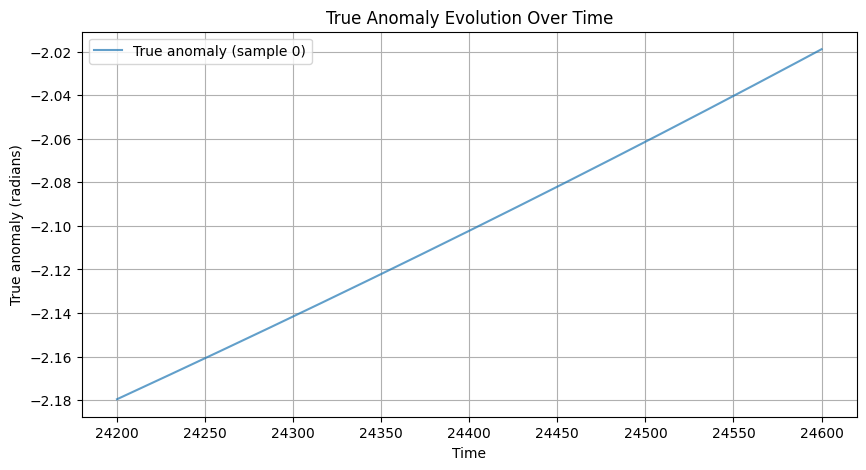

In [489]:
# Flatten the chain and discard burn-in
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

# Choose times to compute f (you can use observed t or a regular grid)
times = np.linspace(2.420, 2.460, 500) * 1e4  # if your time is in JD, for example

# Compute f for each sample at each time
from tqdm import tqdm

f_all = []
for sample in tqdm(flat_samples):  # Only a subset for speed
    e, gamma, omega, T0 = sample
    omega_rad = np.radians(omega)
    M = 2 * np.pi * (times - T0) / P
    E = kepler_eqn(M, e)
    f = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                       np.sqrt(1 - e) * np.cos(E / 2))
    f_all.append(f)

f_all = np.array(f_all)  # shape = (n_samples, len(times))

# Plot: e.g., true anomaly vs time for median sample
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(times, f_all[0], label='True anomaly (sample 0)', alpha=0.7)
plt.xlabel("Time")
plt.ylabel("True anomaly (radians)")
plt.title("True Anomaly Evolution Over Time")
plt.grid(True)
plt.legend()
plt.show()


In [470]:
# Flatten the chain and discard burn-in
samples = sampler.get_chain(discard=10000, thin=15, flat=True)

# Best-fit parameters = median of the posterior
best_fit = np.median(samples, axis=0)
e_best, gamma_best, omega_best, T0_best = best_fit


In [471]:
rv_model = keplerian_model(t, P, K, e_best, gamma_best, omega_best, T0_best, offset)


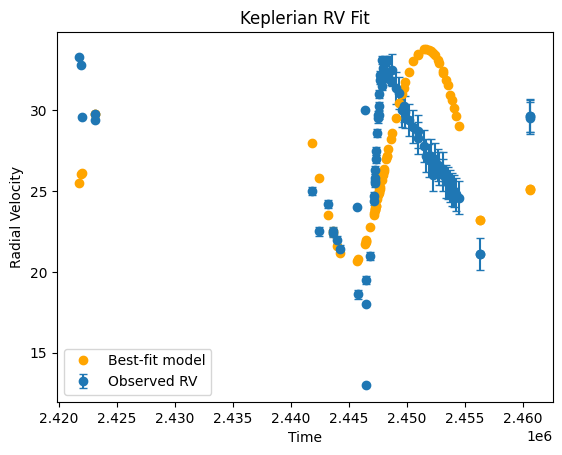

In [476]:
import matplotlib.pyplot as plt

plt.errorbar(t, rv_obs, yerr=rv_err, fmt='o', label='Observed RV', capsize=3)
plt.plot(t, rv_model, label='Best-fit model',  color='orange', marker='o',linestyle='none')

#t_grid = np.linspace(2.420, 2.460, 1000)
#rv_grid = keplerian_model(t_grid, P, K, e_best, gamma_best, omega_best, T0_best, offset)
#plt.plot(t_grid, rv_grid)

plt.xlabel("Time")
plt.ylabel("Radial Velocity")
plt.legend()
plt.title("Keplerian RV Fit")
plt.show()


In [493]:
import numpy as np

# Flatten chain after burn-in and thinning
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

# Parameter names for printing
param_names = ["e", "gamma", "omega (deg)", "T0"]

# Print median and ±1σ for each parameter
for i in range(flat_samples.shape[1]):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{param_names[i]} = {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")


e = 0.0792 (+0.4811, -0.0790)
gamma = 25.6227 (+0.9250, -10.6227)
omega (deg) = -174.0118 (+84.7808, -5.9882)
T0 = 1382.1637 (+411.8244, -110.8173)


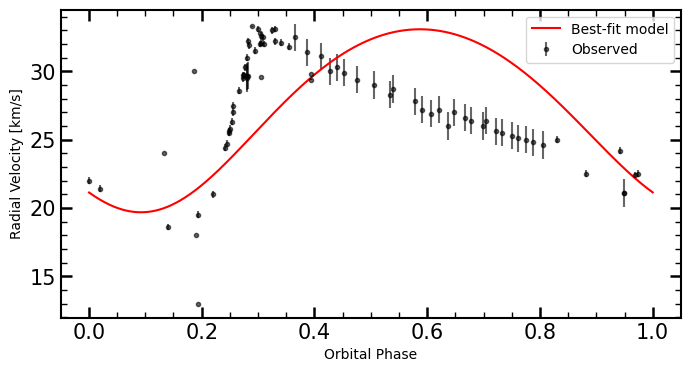

In [494]:
# Phase fold
phase = (t % P) / P
t_grid = np.linspace(t.min(), t.max(), 1000)
phase_grid = (t_grid % P) / P

# Best-fit params from MCMC
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
e_mcmc, gamma_mcmc, omega_mcmc, T0_mcmc = np.median(flat_samples, axis=0)

# Model on dense grid
rv_model_grid = keplerian_model(t_grid, P, K, e_mcmc, gamma_mcmc, omega_mcmc, T0_mcmc, offset)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax = plotparams(ax)
ax.errorbar(phase, rv_obs, yerr=rv_err, fmt='.', color='black', alpha=0.6, label='Observed')
ax.plot(np.sort(phase_grid), rv_model_grid[np.argsort(phase_grid)], color='red', label='Best-fit model')
ax.set_xlabel('Orbital Phase')
ax.set_ylabel('Radial Velocity [km/s]')
ax.legend()


In [478]:
gamma_samples = flat_samples[:, 2]  # Adjust index if needed


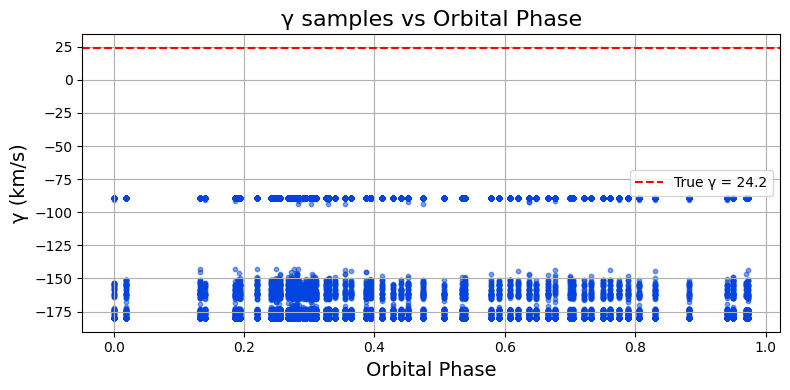

In [482]:
# Get MCMC samples
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
gamma_samples = flat_samples[:, 2]  # Assuming gamma is at index 2

# Generate random times and phases for visual distribution
random_times = np.random.choice(t, size=len(gamma_samples))
phase = (random_times % P) / P

# Plot gamma vs phase
plt.figure(figsize=(8, 4))
plt.scatter(phase, gamma_samples, alpha=0.5, s=10, color='xkcd:blue')
plt.axhline(24.2, color='red', linestyle='--', label='True γ = 24.2')

plt.xlabel('Orbital Phase', fontsize=14)
plt.ylabel('γ (km/s)', fontsize=14)
plt.title('γ samples vs Orbital Phase', fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [486]:
params

array([ 5.80e-01,  2.42e+01, -8.00e+01,  1.40e+03])

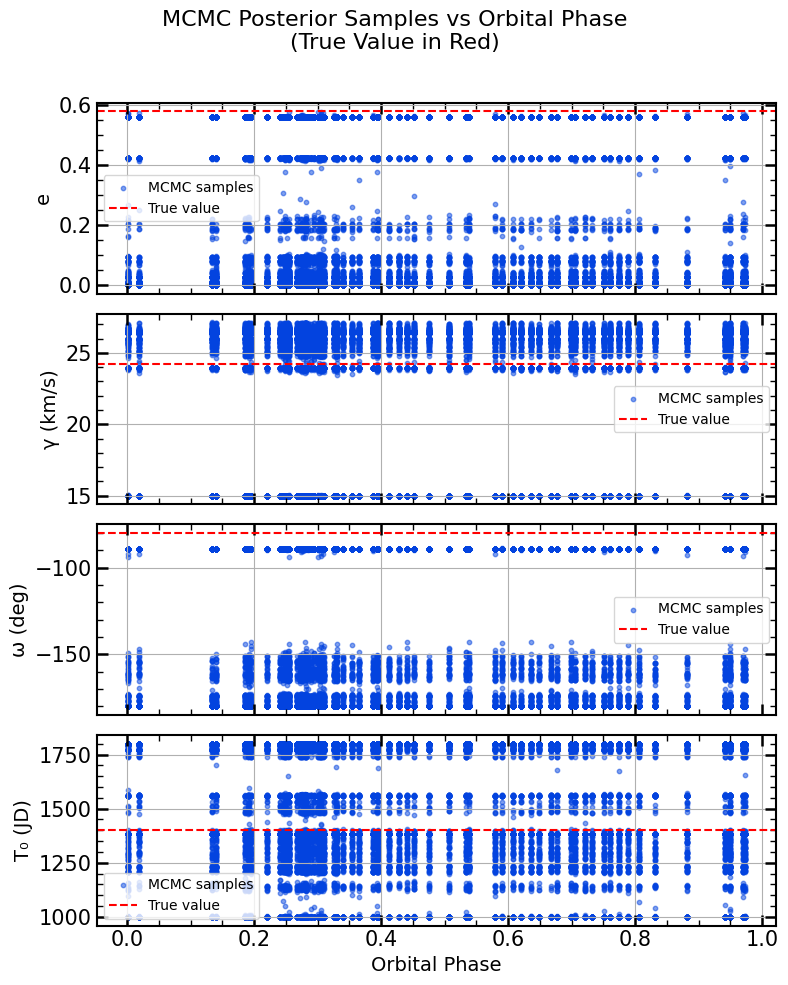

In [492]:
import matplotlib.pyplot as plt
import numpy as np

# --- True/simulated values (set these from your simulation) ---
e_true     = 0.58
gamma_true = 24.2
omega_true = -80.0
T0_true    = 1400.0

# 1. Flatten MCMC samples
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

# 2. Extract parameters
e_samples     = flat_samples[:, 0]
gamma_samples = flat_samples[:, 1]
omega_samples = flat_samples[:, 2]
T0_samples    = flat_samples[:, 3]

# 3. Randomly sample times and compute phase
n_samples = len(flat_samples)
random_times = np.random.choice(t, size=n_samples)
phase = (random_times % P) / P
sorted_indices = np.argsort(phase)
sorted_phase = phase[sorted_indices]

# 4. Organize parameters
params = [e_samples, gamma_samples, omega_samples, T0_samples]
params_sorted = [p[sorted_indices] for p in params]
labels = ['e', 'γ (km/s)', 'ω (deg)', 'T₀ (JD)']
true_values = [e_true, gamma_true, omega_true, T0_true]

# 5. Plot
fig, axes = plt.subplots(len(params), 1, figsize=(8, 10), sharex=True)
fig.subplots_adjust(hspace=0.35)

for i, (param, label, true_val) in enumerate(zip(params_sorted, labels, true_values)):
    ax = axes[i]
    ax = plotparams(ax)  # Your custom style
    ax.scatter(sorted_phase, param, s=10, alpha=0.5, color='xkcd:blue', label='MCMC samples')
    ax.axhline(true_val, color='red', linestyle='--', linewidth=1.5, label='True value')
    ax.set_ylabel(label, fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=10)

axes[-1].set_xlabel("Orbital Phase", fontsize=14)
fig.suptitle("MCMC Posterior Samples vs Orbital Phase\n(True Value in Red)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


__print chi sq__

check if the gamma follows a parabola

In [495]:
# ---------------------------------------------------------------
# χ² and reduced-χ² for the best-fit model (uses gamma_best, etc.)
# ---------------------------------------------------------------
e_best, gamma_best, omega_best, T0_best = best_fit           # already defined
rv_model_best = keplerian_model(t, P, K,
                                e_best, gamma_best,
                                omega_best, T0_best,
                                offset)

# χ² = Σ[(obs − model)/σ]²
chi2 = np.sum(((rv_obs - rv_model_best)/rv_err)**2)

# reduced χ²  (ν = N − k,  k = # free parameters = 4 here)
nu = len(rv_obs) - 4
chi2_red = chi2 / nu

print(f"χ² (best-fit)       : {chi2:.3f}")
print(f"reduced χ² (ν={nu}) : {chi2_red:.3f}")


χ² (best-fit)       : 28608429.993
reduced χ² (ν=75) : 381445.733


In [425]:
samples = sampler.get_chain() # "Get the stored chain of MCMC data" ; what is the difference between this and get_blobs()

In [426]:
print(sampler.get_chain().shape, flat_samples.shape)

import numpy as np

for i, label in enumerate(parameter_labels):
    samples = flat_samples[:, i]
    print(f"{label}: mean={np.mean(samples):.4f}, std={np.std(samples):.4f}, range=({np.min(samples):.4f}, {np.max(samples):.4f})")


(50000, 10, 5) (400000, 5)
Eccentricity $e$: mean=0.3862, std=0.3886, range=(0.0837, 0.9921)
f(M)[M_sun]: mean=-0.2338, std=0.3852, range=(-0.8337, 0.0694)
COM velocity $\gamma$ (km/s): mean=489.6454, std=281.1383, range=(57.7130, 682.9240)
$\omega$: mean=359.8516, std=0.0069, range=(359.8371, 359.8584)
T0-2.42x10^6[d]: mean=11062.3179, std=6907.6977, range=(2017.7528, 18979.7502)


In [413]:
import numpy as np

# Index of omega in flat_samples
omega_idx = 3  # for example
omega = flat_samples[:, omega_idx]

# Force omega into [0, 360)
omega = np.mod(omega, 360)
flat_samples[:, omega_idx] = omega


In [414]:
import numpy as np

omega_vals = np.mod(flat_samples[:, 4], 360)  # if omega is the 5th param
median = np.median(omega_vals)
lower = np.percentile(omega_vals, 16)
upper = np.percentile(omega_vals, 84)

print(f"omega = {median:.1f} +{upper - median:.1f}/-{median - lower:.1f} degrees")


omega = 165.7 +144.6/-92.2 degrees


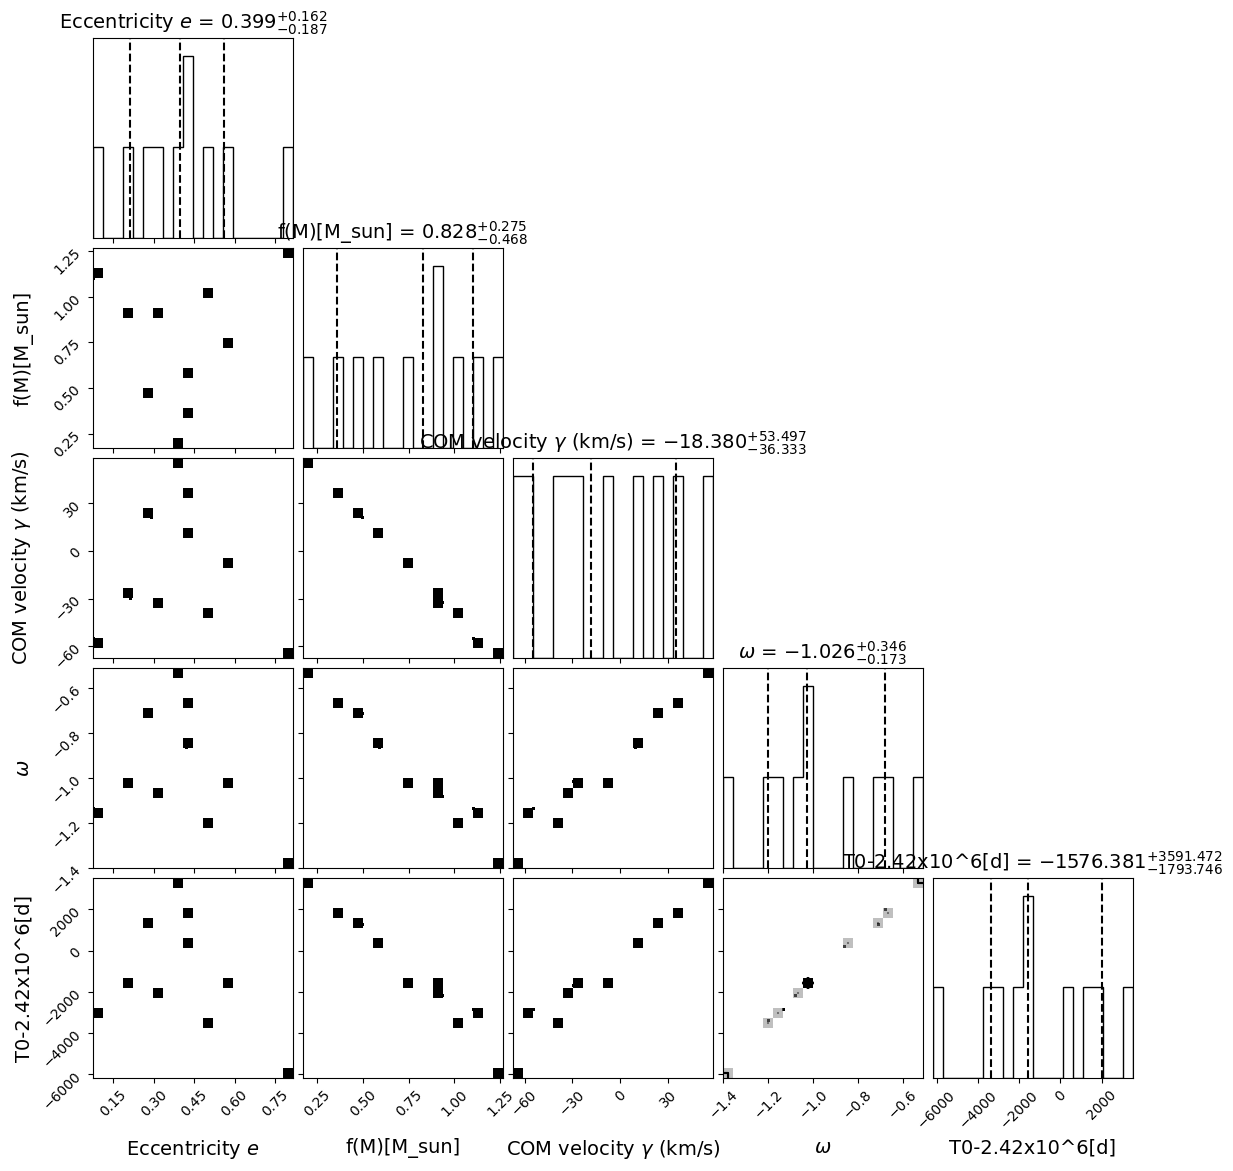

In [427]:
import corner
import matplotlib.pyplot as plt

# need to alter the parameter names
parameter_labels = [
    #"Period $P$ (days)", 
    #"Semi-amplitude $K$ (km/s)", #is this somehow in the wrong units?
    "Eccentricity $e$", 
    "f(M)[M_sun]", # can this even be negative
    "COM velocity $\\gamma$ (km/s)", # I dont think this is meant to be negative
    "$\\omega$", # uh .. help
    "T0-2.42x10^6[d]"
]

# Remove burn-in (what does burning in mean-- they did it in the paper)
burn = 10000  # they burned the first 10,000 iterations
flat_samples = sampler.get_chain(discard=burn, flat=True)

# Plot with larger size and fonts?
fig = corner.corner(
    flat_samples,
    labels=parameter_labels,
    label_kwargs={"fontsize": 14},
    show_titles=True,
    title_kwargs={"fontsize": 14},
    quantiles=[0.16, 0.5, 0.84],
    title_fmt=".3f",
    figsize=(12, 12)
)

plt.show()
#what does the root too few points error message mean

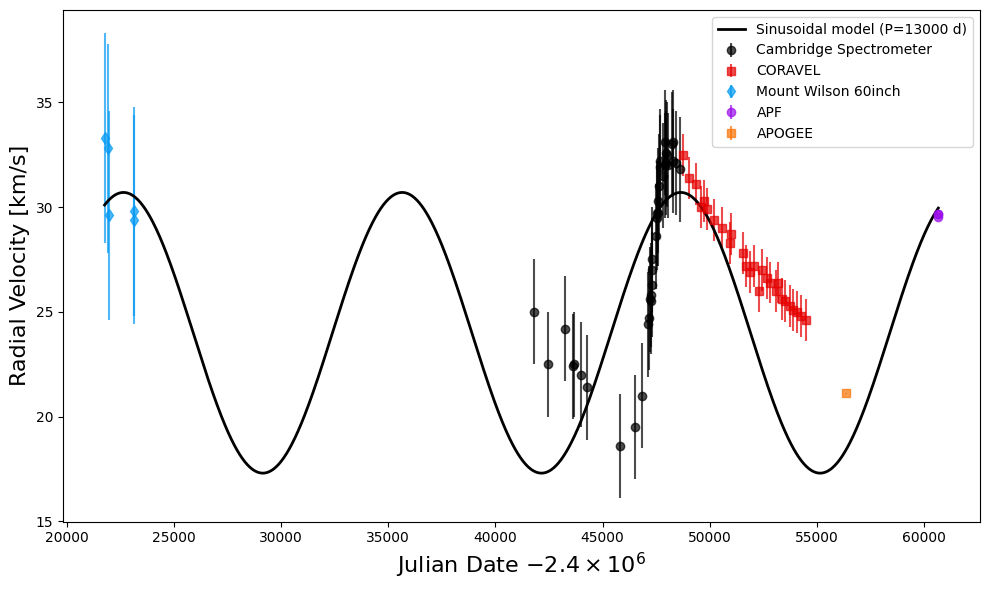

In [152]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for sinusoidal RV model
P = 13000             # Period in days
K = 6.7             # RV semi-amplitude in km/s 
T0 = 1400 #df['JD'].max()  # Reference time (e.g., time of periastron)
gamma = 24         # Systemic velocity (km/s), adjust to fit vertical offset

# Define simple circular RV model
def rv_sinusoid(t, P, K, T0, gamma):
    phase = 2 * np.pi * (t - T0) / P
    return gamma + K * np.sin(phase)

# Generate smooth model curve over time span of data
t_grid = np.linspace(df['JD'].min(), df['JD'].max(), 1000)
rv_modelz = rv_sinusoid(t_grid, P, K, T0, gamma)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data with error bars
for instrument, marker, color in zip(instrument_list, markers, colors):
    subset = df[df.Instrument == instrument]
    ax.errorbar(subset['JD'] - 2.4e6, subset['RV'], yerr=subset['RV_err'],
                fmt=marker, color=color, label=instrument, alpha=0.7)

# Overlay sinusoidal model
ax.plot(t_grid - 2.4e6, rv_modelz, 'k-', lw=2, label=f'Sinusoidal model (P={P} d)')

# Labels and legend

ax.set_xlabel(r'Julian Date $- 2.4 \times 10^6$', fontsize=16)
ax.set_ylabel('Radial Velocity [km/s]', fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()


I need to fix K and let the other parameters vary

In [170]:
# Ensure K_fixed is set
K_fixed = 6.7  # Fixed value for K

# The prior function is applied to the fixed parameters
def log_prior2(params_new):
    P, e, f, omega, T0, gamma = params_new  # Unpack params_new (no need for params)
    if 0 < e < 1 and P > 0:  # Apply uniform prior conditions
        return 0.0  # Uniform prior
    return -np.inf  # If prior conditions are not met, return a very low value

# Log-likelihood function based on the given model and data
def log_likelihood2(params_new, t, rv_obs, offset, K_fixed):
    P, e,f, omega, T0, gamma = params_new  # Unpack params_new
    model_rv = keplerian_model(t, P, K_fixed, e,f, omega, T0, gamma, offset)  # Model predictions
    sigma2 = np.var(rv_obs)  # Variance of observed RVs
    return -0.5 * np.sum((rv_obs - model_rv)**2 / sigma2 + np.log(2 * np.pi * sigma2))  # Likelihood formula

# Log-probability function (prior + likelihood)
def log_probability2(params_new, t, rv_obs, offset, K_fixed):
    lp = log_prior2(params_new)  # Calculate log prior based on params_new
    if not np.isfinite(lp):
        return -np.inf  # Reject samples that don't meet prior conditions
    return lp + log_likelihood2(params_new, t, rv_obs, offset, K_fixed)  # Return the sum of prior and likelihood

# Set the initial values for the parameters (without '_guess' suffix)
params_new = [P, e, f,omega, T0, gamma]  # Replace with your actual values for P, e, omega, T0, and gamma
ndim = len(params_new)  # Number of parameters to estimate
nwalkers = 2 * ndim  # Number of walkers (usually 2 * ndim)
# give each parameter its own step size

scale = [130, 0.01, 0.0022, 0.242, -0.8, 14]

# Initialize positions for the walkers with a small perturbation around the initial guess
pos = np.array(params_new) + scale * np.random.randn(nwalkers, ndim)

# Create the MCMC sampler using only params_new in log_probability
sampler_instance = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, rv_obs, offset, K_fixed))

# Run the MCMC chain (ensure sampler_instance is used)
chain = sampler_instance.run_mcmc(pos, 50000, progress=True)



100%|████████████████████████████████████| 50000/50000 [01:39<00:00, 502.11it/s]


In [171]:
samples = sampler_instance.get_chain() # "Get the stored chain of MCMC data" ; what is the difference between this and get_blobs()



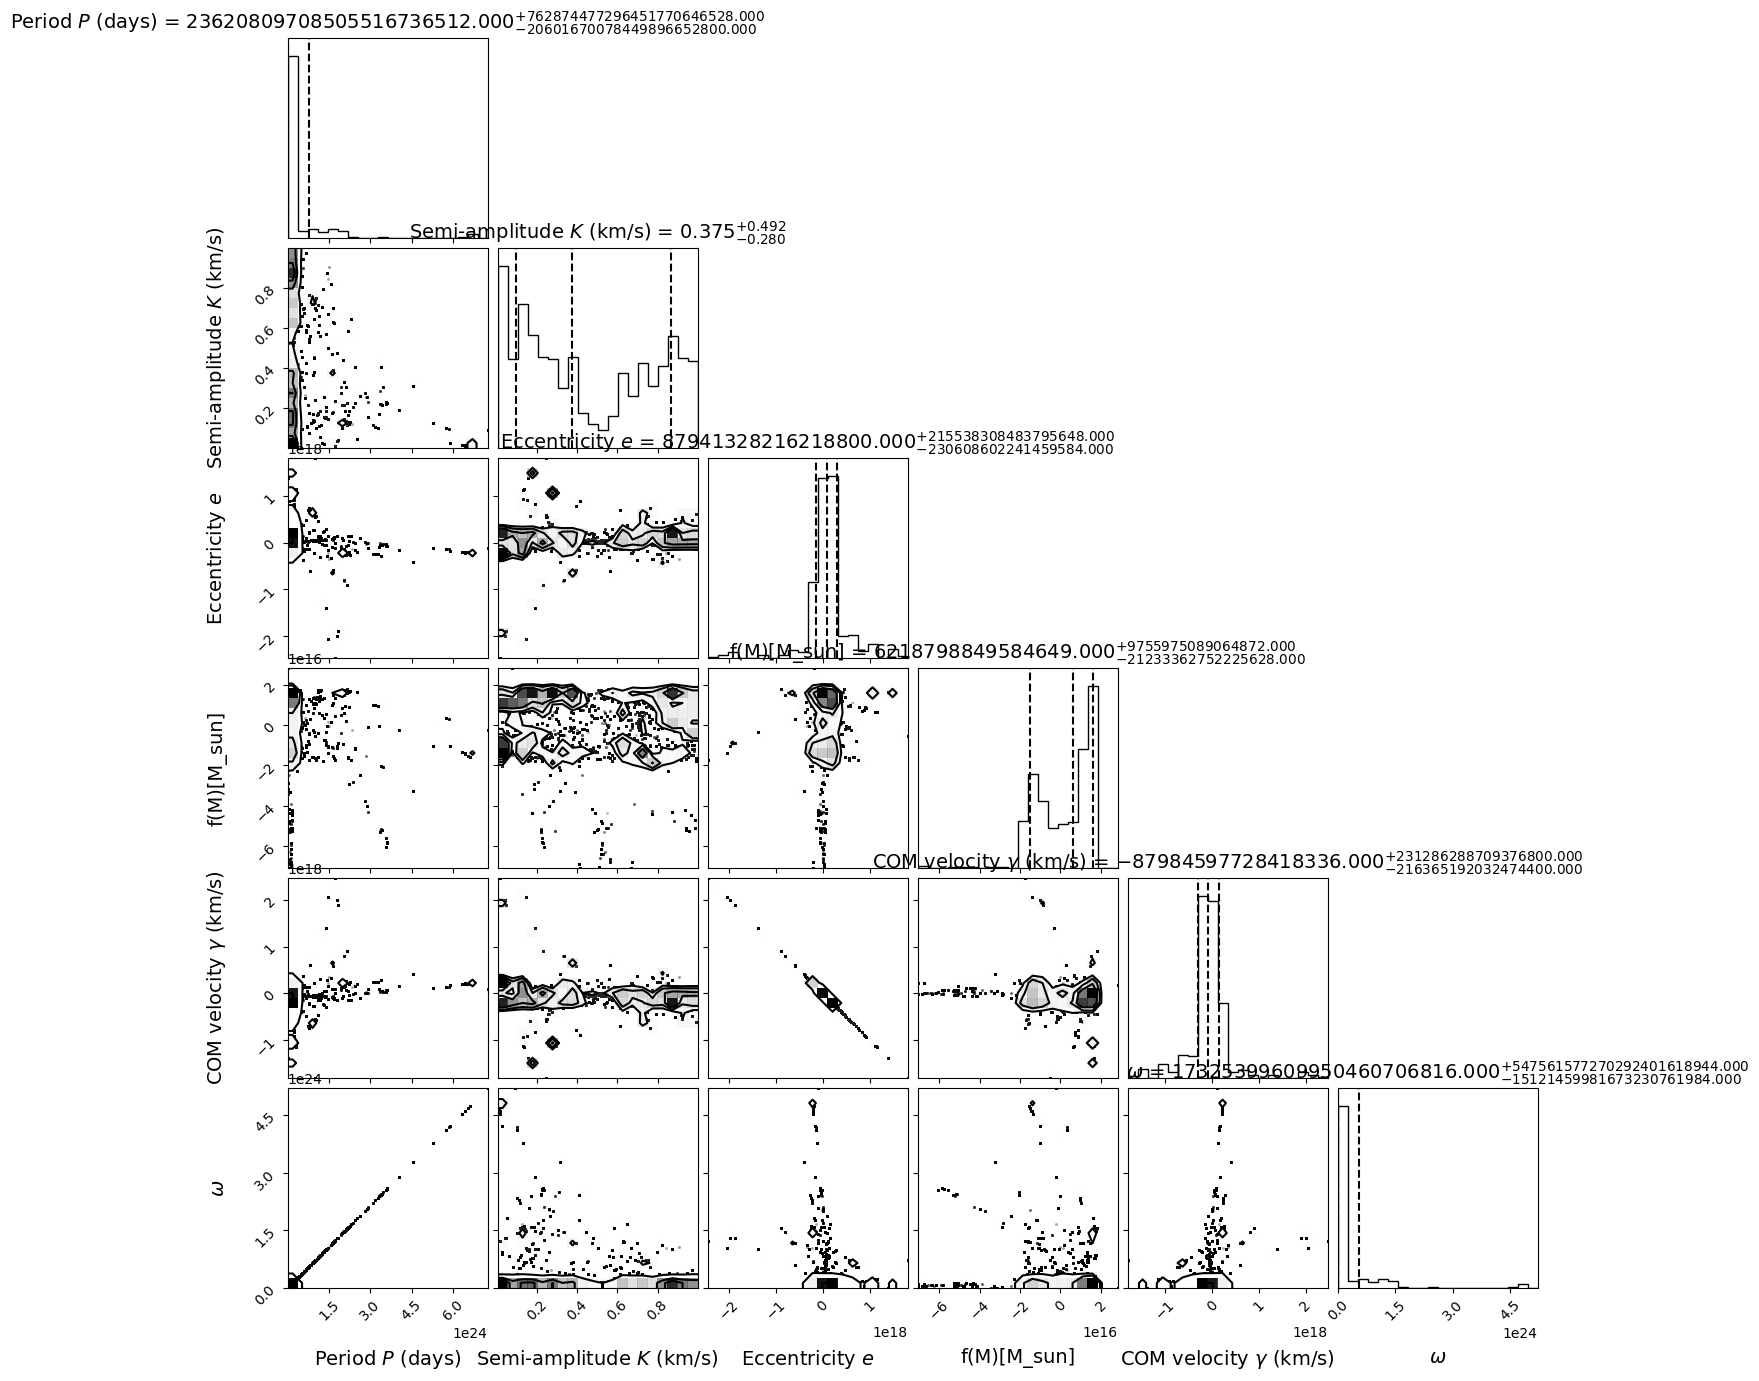

In [172]:
import corner
import matplotlib.pyplot as plt

# need to alter the parameter names
parameter_labels = [
    "Period $P$ (days)", 
    "Semi-amplitude $K$ (km/s)", #is this somehow in the wrong units?
    "Eccentricity $e$", 
    "f(M)[M_sun]", # can this even be negative
    "COM velocity $\\gamma$ (km/s)", # I dont think this is meant to be negative
    "$\\omega$", # uh .. help
    "T0-2.42x10^6[d]",
    "jitter?" #what even is this why is this here
]

# Remove burn-in (what does burning in mean-- they did it in the paper)
burn = 10000  # they burned the first 10,000 iterations
flat_samples2 = sampler_instance.get_chain(discard=burn, flat=True)

# Plot with larger size and fonts?
fig = corner.corner(
    flat_samples2,
    labels=parameter_labels,
    label_kwargs={"fontsize": 14},
    show_titles=True,
    title_kwargs={"fontsize": 14},
    quantiles=[0.16, 0.5, 0.84],
    title_fmt=".3f",
    figsize=(12, 12)
)

plt.show()
#what does the root too few points error message mean

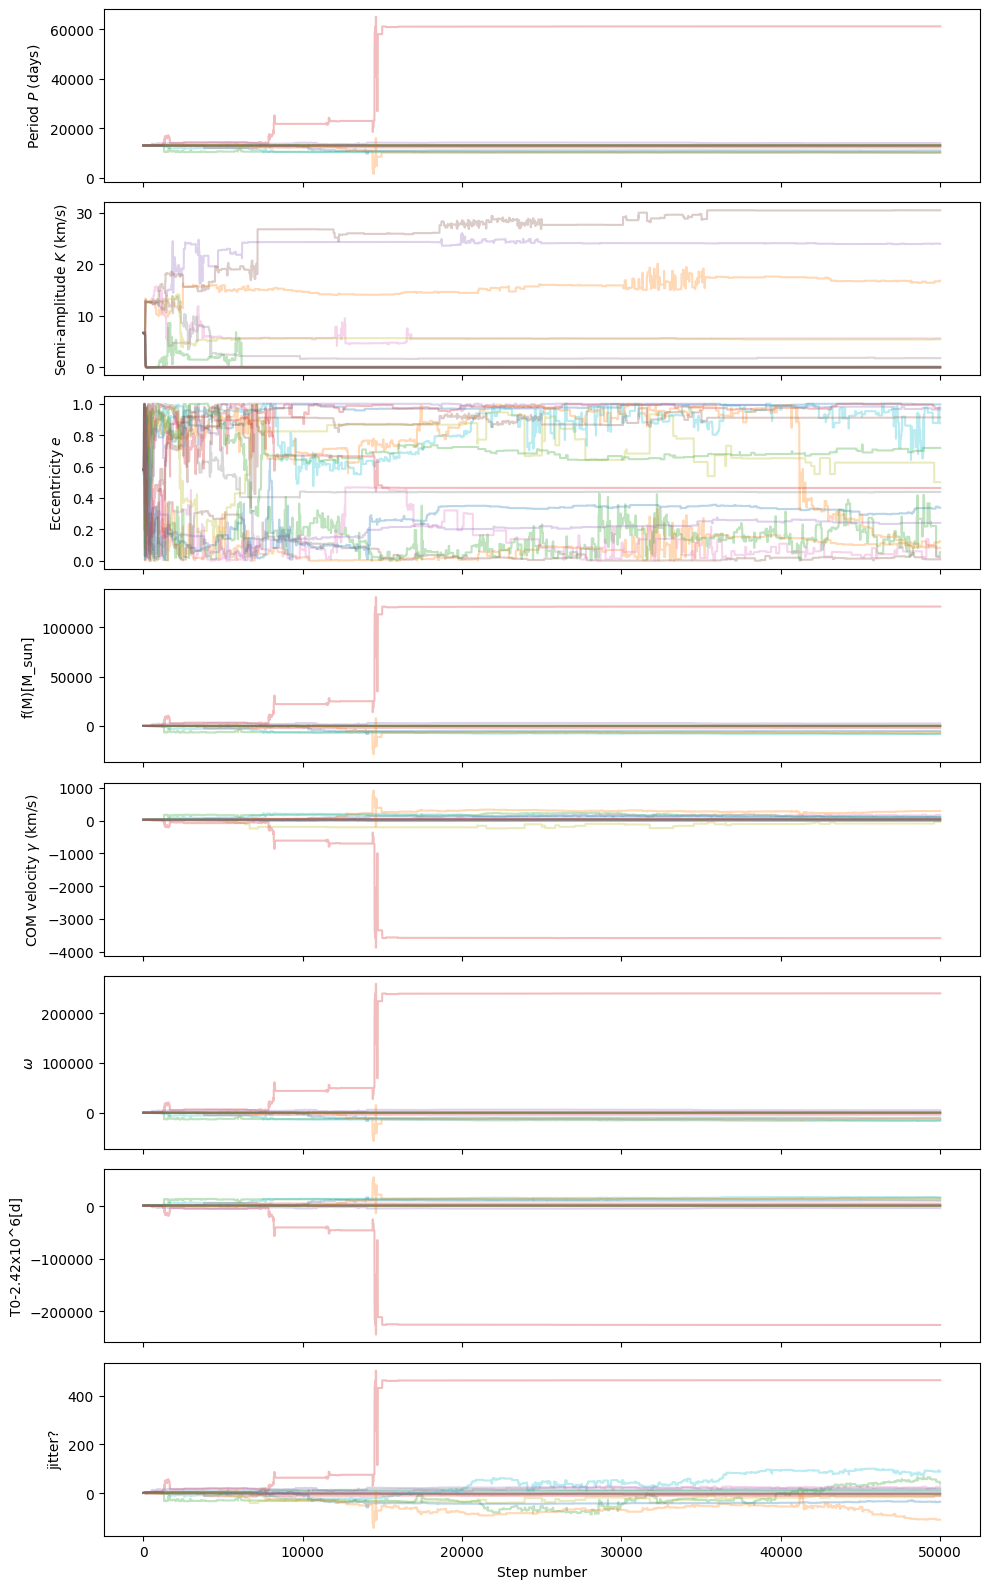

In [111]:
import matplotlib.pyplot as plt

samples = sampler.get_chain()
labels = parameter_labels  # same labels as before

fig, axes = plt.subplots(ndim, figsize=(10, 2 * ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(samples[:, walker, i], alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()


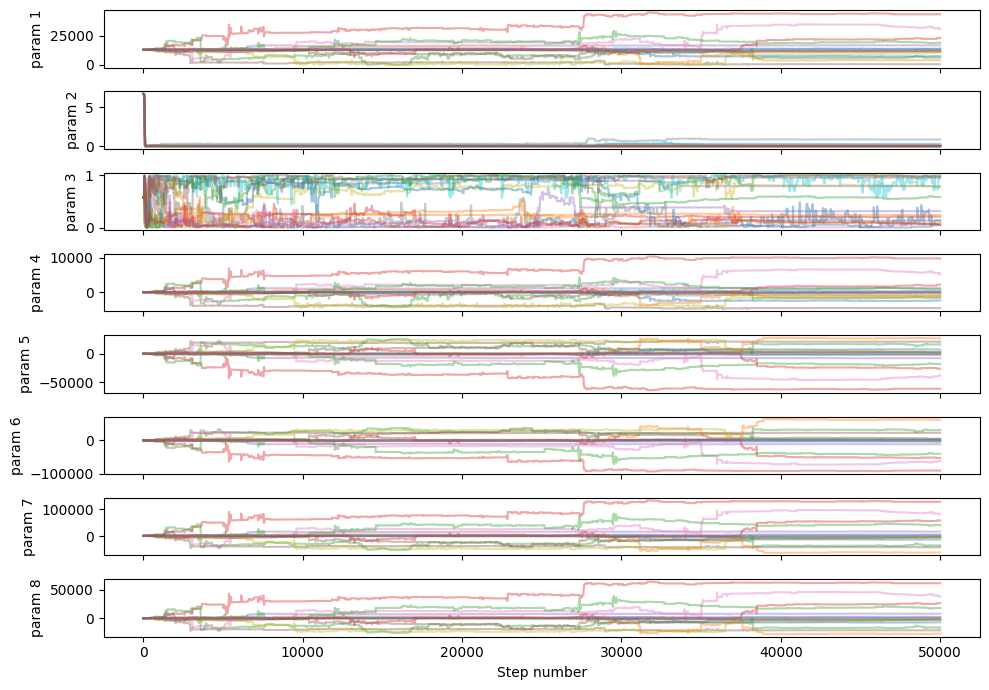

In [87]:
import matplotlib.pyplot as plt

samples = sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)

nparams = samples.shape[2]
fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)

for i in range(nparams):
    ax = axes[i]
    for walker in range(samples.shape[1]):
        ax.plot(samples[:, walker, i], alpha=0.4)
    ax.set_ylabel(f"param {i+1}")
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()
